data source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
d=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
d.shape

(7043, 21)

In [6]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
d.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
print(d.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [12]:
d.SeniorCitizen.value_counts()

,count
SeniorCitizen,
0,5901
1,1142


In [17]:
for i in d.columns:
  print(d[i].value_counts())
  print("\n")

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64


gender
Male      3555
Female    3488
Name: count, dtype: int64


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents
No     4933
Yes    2110
Name: count, dtype: int64


tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


PhoneService
Yes    6361
No      682
Name: count, dtype: int64


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity
No                     3498
Yes                    2019
No inte

In [25]:
print(d.Churn.value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [26]:
churnnumber=d.Churn.value_counts().tolist()

In [31]:
print(f"churn rate : {(churnnumber[1]/len(d))*100} %")

churn rate : 26.536987079369588 %


In [32]:
d['TotalCharges'] = pd.to_numeric(d['TotalCharges'], errors='coerce')#keeping errors null

In [33]:
d['TotalCharges'].isnull().sum()

np.int64(11)

In [37]:
import missingno as msno

<Axes: >

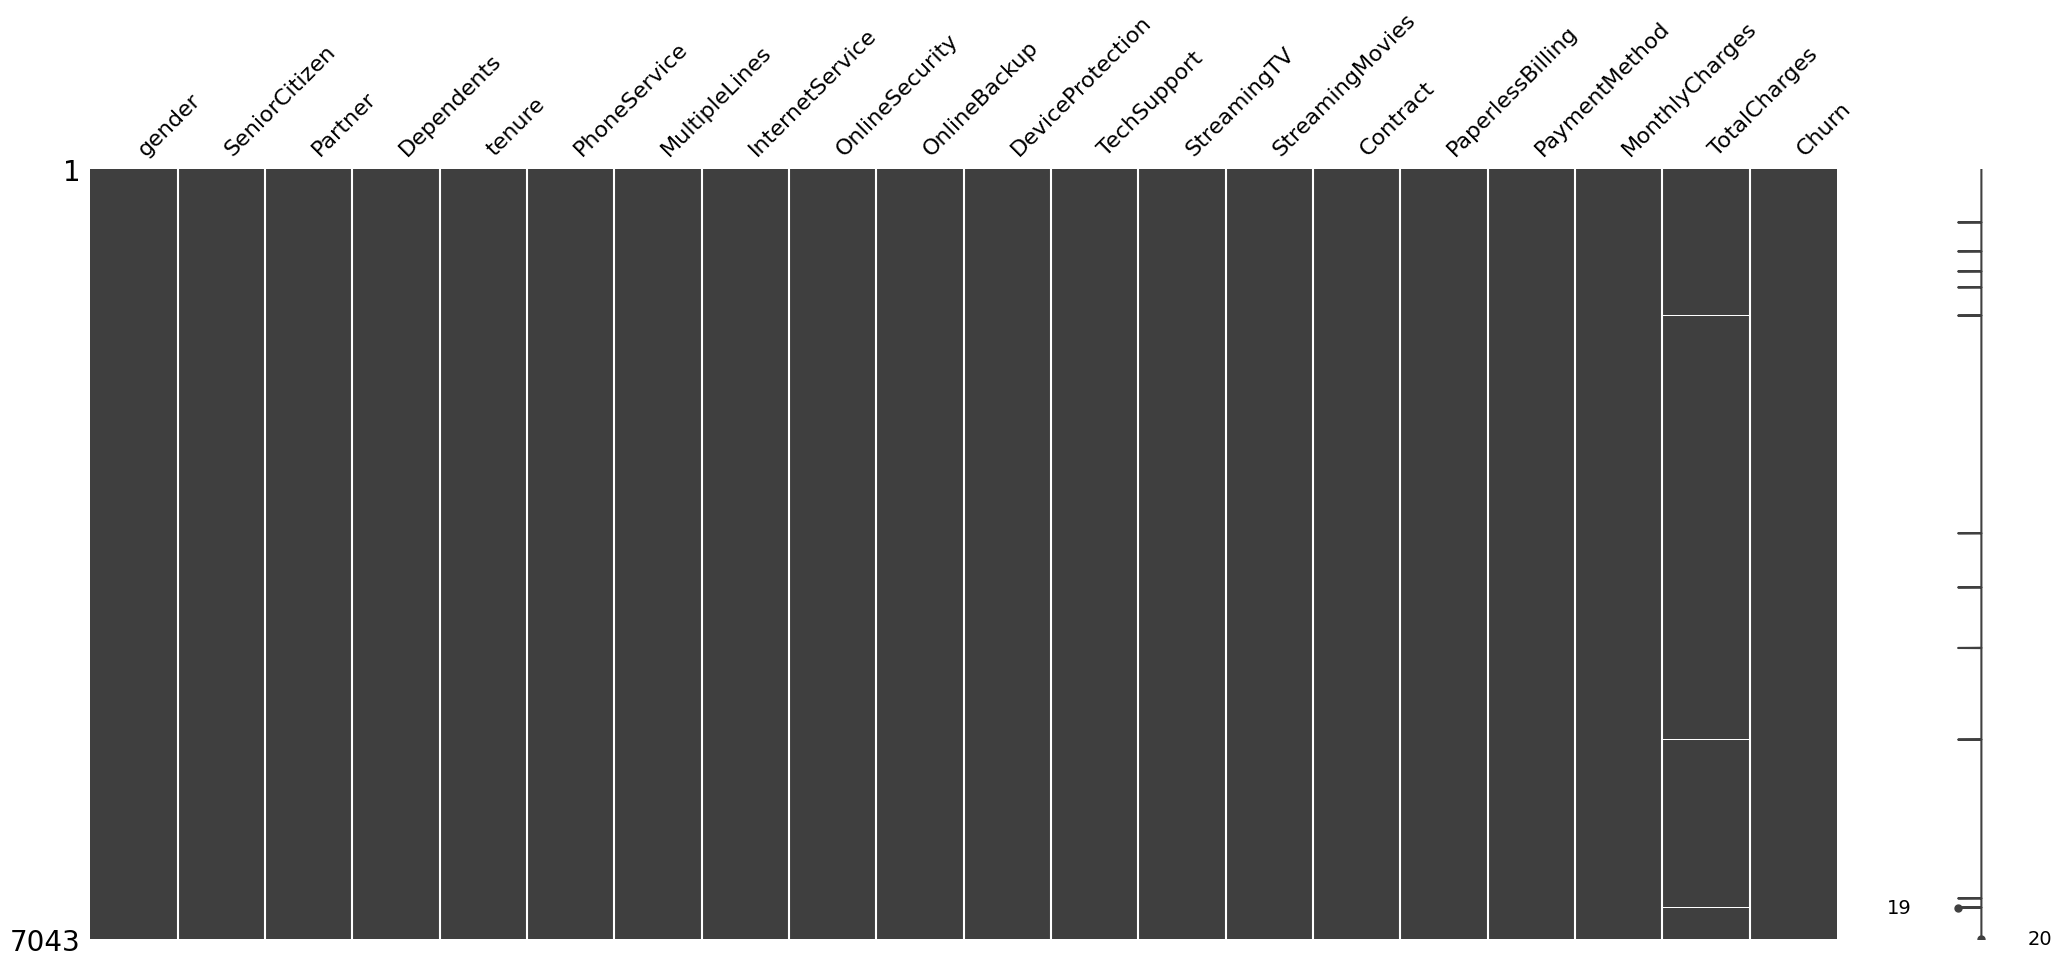

In [38]:
msno.matrix(d)

In [34]:
d.drop(columns=['customerID'], inplace=True)

In [35]:
d['SeniorCitizen'] = d['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [41]:
d['TotalCharges'] = d['TotalCharges'].fillna(0)

In [42]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


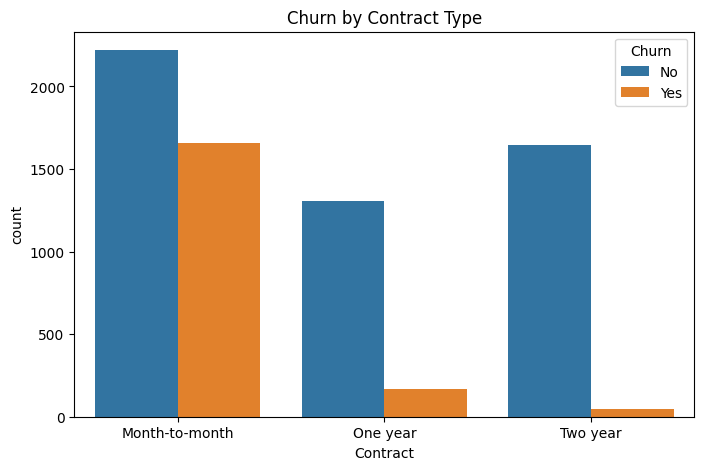

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))

sns.countplot(x='Contract', hue='Churn', data=d)

plt.title('Churn by Contract Type')
plt.show()

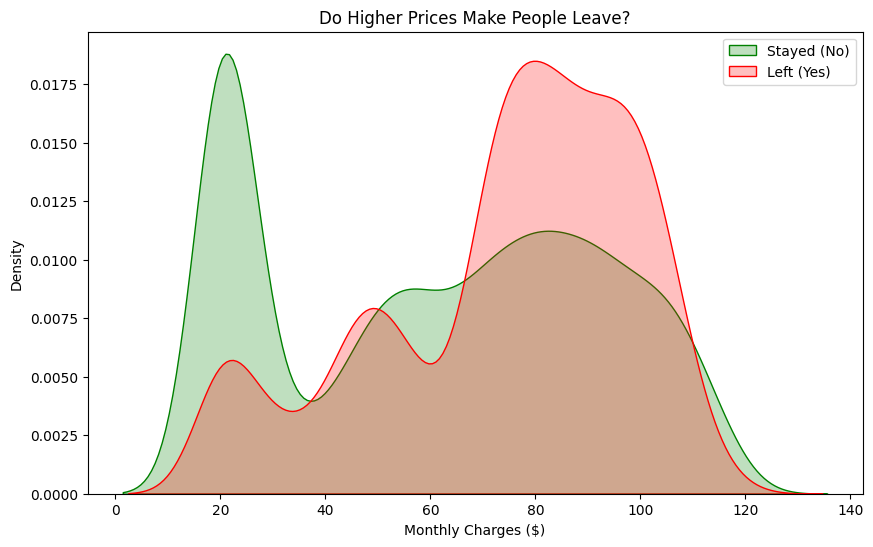

In [45]:
plt.figure(figsize=(10, 6))


sns.kdeplot(d[d['Churn']=='No']['MonthlyCharges'], color='green', fill=True, label='Stayed (No)')

#Red = People who Left
sns.kdeplot(d[d['Churn']=='Yes']['MonthlyCharges'], color='red', fill=True, label='Left (Yes)')

plt.title('Do Higher Prices Make People Leave?')
plt.xlabel('Monthly Charges ($)')
plt.legend()
plt.show()

Customers paying high monthly fees are much more likely to churn.

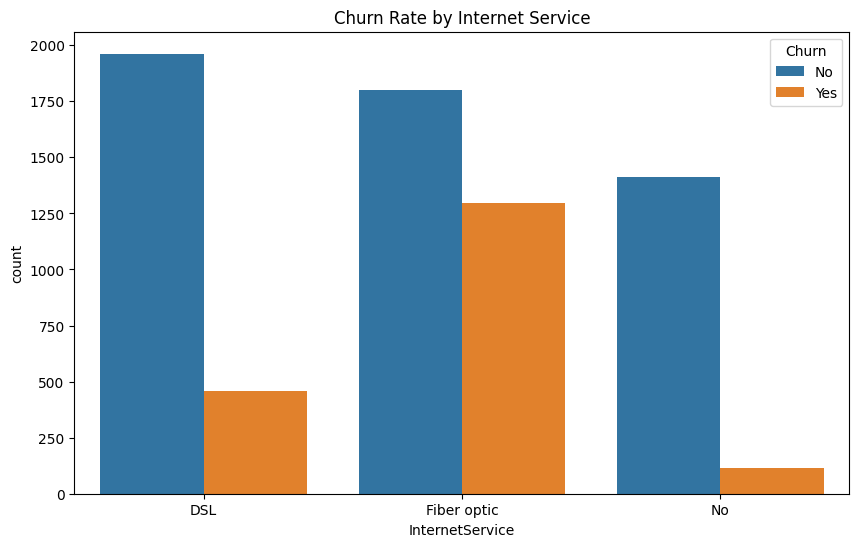

In [51]:
plt.figure(figsize=(10, 6))

#Comparing Churn rates across different Internet Services
sns.countplot(x='InternetService', hue='Churn', data=d)

plt.title('Churn Rate by Internet Service')
plt.show()

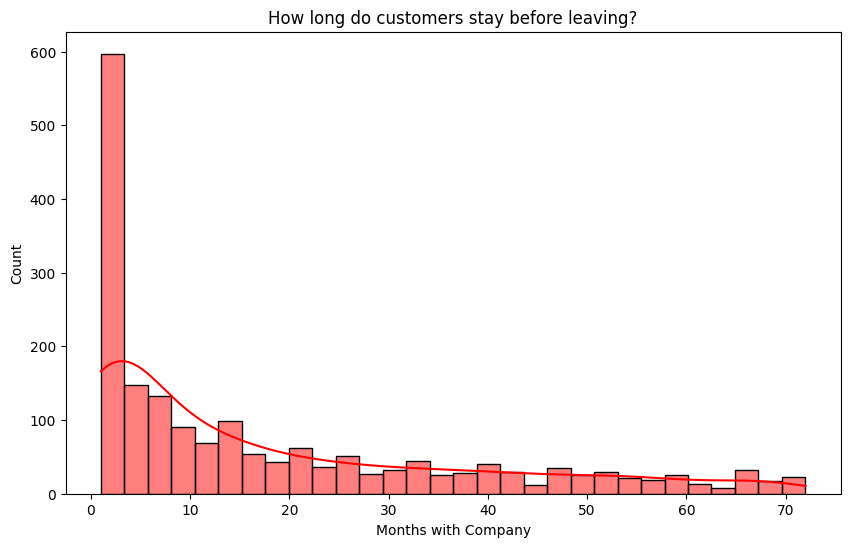

In [48]:
plt.figure(figsize=(10, 6))

sns.histplot(x='tenure', data=d[d['Churn']=='Yes'], bins=30, color='red', kde=True)

plt.title('How long do customers stay before leaving?')
plt.xlabel('Months with Company')
plt.show()

In [52]:
d.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
# 1. Convert Churn to Numbers (Yes=1, No=0) so we can calculate rates
d['Churn'] = d['Churn'].map({'Yes': 1, 'No': 0})

# 2. Check if Gender matters (Spoiler: It won't)
print("Churn Rate by Gender:")
print(d.groupby('gender')['Churn'].mean())


Churn Rate by Gender:
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


In [54]:
print("--- FAMILY IMPACT ---")
print(d.groupby('Partner')['Churn'].mean())
print(d.groupby('Dependents')['Churn'].mean())

--- FAMILY IMPACT ---
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64


In [59]:
print("\n--- PAYMENT METHOD IMPACT ---")
print(d.groupby('PaymentMethod')['Churn'].mean())


--- PAYMENT METHOD IMPACT ---
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64


/tmp/ipython-input-3513407308.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TechSupport', y='Churn', data=d, ax=axes[0], palette="Blues_d", errorbar=None)
/tmp/ipython-input-3513407308.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='OnlineSecurity', y='Churn', data=d, ax=axes[1], palette="Greens_d", errorbar=None)


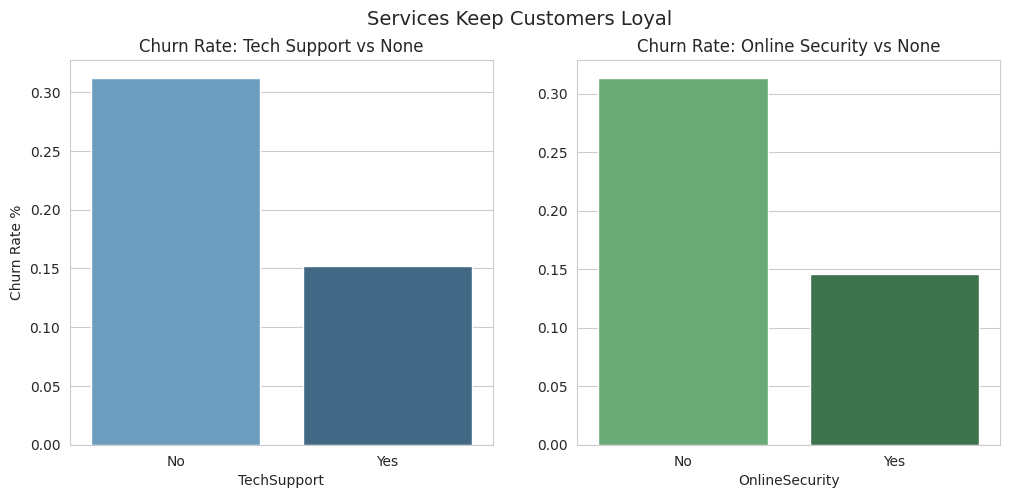

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_style("whitegrid")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Chart 1: Tech Support
sns.barplot(x='TechSupport', y='Churn', data=d, ax=axes[0], palette="Blues_d", errorbar=None)
axes[0].set_title('Churn Rate: Tech Support vs None')
axes[0].set_ylabel('Churn Rate %')

#Chart 2: Online Security
sns.barplot(x='OnlineSecurity', y='Churn', data=d, ax=axes[1], palette="Greens_d", errorbar=None)
axes[1].set_title('Churn Rate: Online Security vs None')
axes[1].set_ylabel('')

plt.suptitle('Services Keep Customers Loyal', fontsize=14)
plt.show()



/tmp/ipython-input-2512958141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Partner', y='Churn', data=d, ax=axes[0], palette="Pastel1",
/tmp/ipython-input-2512958141.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dependents', y='Churn', data=d, ax=axes[1], palette="Pastel2",


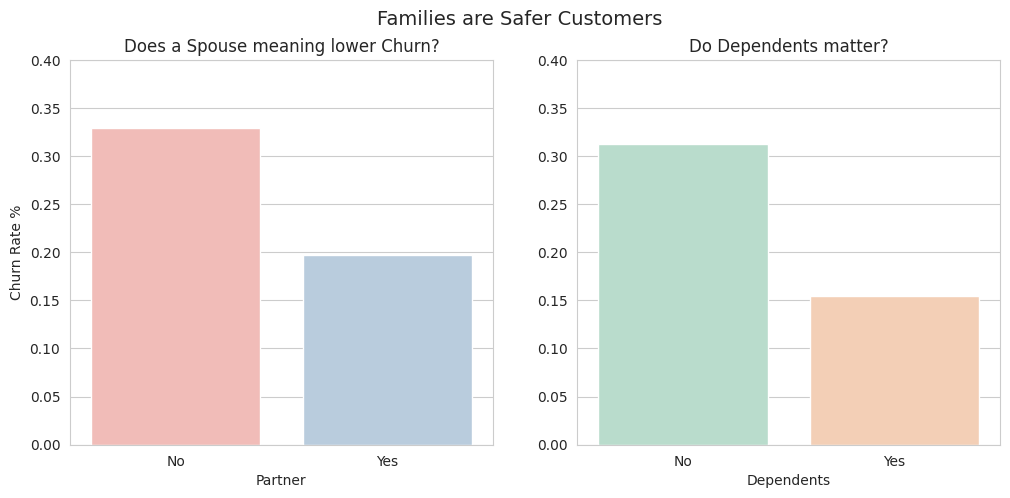

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Partner (Force order: No, Yes)
sns.barplot(x='Partner', y='Churn', data=d, ax=axes[0], palette="Pastel1",
            order=['No', 'Yes'], errorbar=None)
axes[0].set_title('Does a Spouse meaning lower Churn?')
axes[0].set_ylabel('Churn Rate %')
axes[0].set_ylim(0, 0.4)

# Chart 2: Dependents (Force order: No, Yes)
sns.barplot(x='Dependents', y='Churn', data=d, ax=axes[1], palette="Pastel2",
            order=['No', 'Yes'], errorbar=None)
axes[1].set_title('Do Dependents matter?')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 0.4)

plt.suptitle('Families are Safer Customers', fontsize=14)
plt.show()

/tmp/ipython-input-1115844034.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='PaymentMethod', x='Churn', data=d, palette='viridis', errorbar=None)
/tmp/ipython-input-1115844034.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


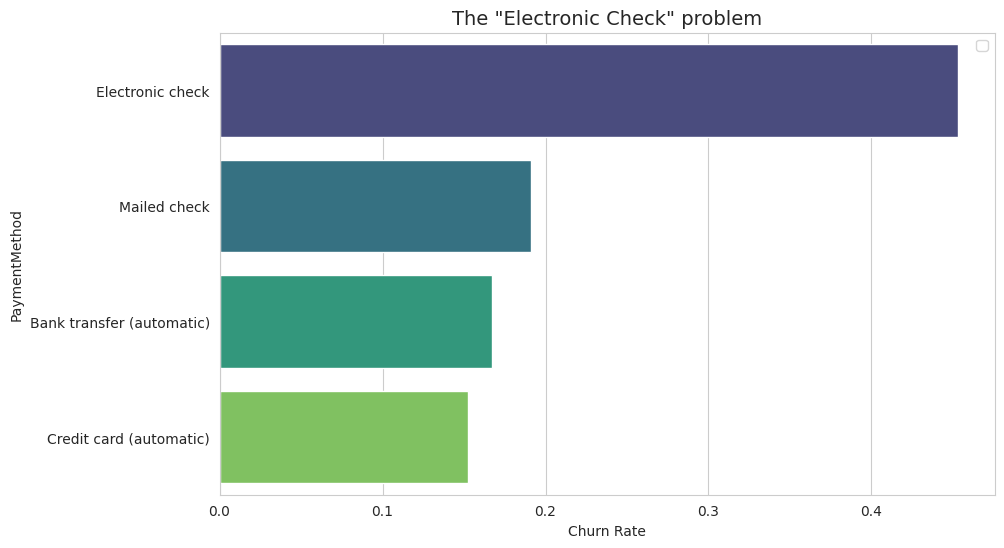

In [76]:
plt.figure(figsize=(10, 6))


sns.barplot(y='PaymentMethod', x='Churn', data=d, palette='viridis', errorbar=None)

plt.title('The "Electronic Check" problem', fontsize=14)
plt.xlabel('Churn Rate')
plt.legend()
plt.show()

/tmp/ipython-input-934841194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


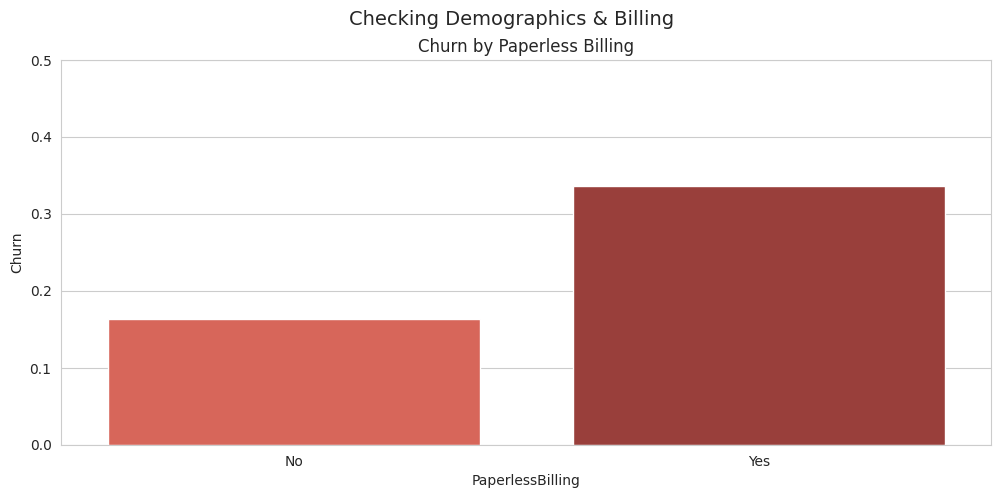

In [93]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    x='PaperlessBilling',
    y='Churn',
    data=d,
    palette="Reds_d",
    order=['No', 'Yes'],
    errorbar=None,
    ax=ax
)

ax.set_title('Churn by Paperless Billing')
ax.set_ylim(0, 0.5)

plt.suptitle('Checking Demographics & Billing', fontsize=14)
plt.show()
